# EDA - Desafio RMI Educação

Exploração dos 5 Parquets educacionais (`aluno`, `escola`, `turma`,
`frequencia`, `avaliacao`) - anonimizados, ano letivo colapsado em 2000.

Resultados em `eda_report.md` (mesma pasta).

## 0. Setup

In [1]:
import os
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import polars as pl
import pyarrow.parquet as pq
import seaborn as sns

pd.set_option("display.max_columns", 80)
pd.set_option("display.width", 160)
sns.set_theme(style="whitegrid", context="notebook")

# Detecta a raiz do projeto independentemente do cwd:
# 1) Se `__file__` existe (script ou kernel jupyter recente), sobe um nível
#    a partir da pasta do notebook (`exploratory_data_analysis/` -> raiz).
# 2) Caso contrário, usa o nome da pasta atual como pista.
PROJECT_ROOT = (
    Path(__file__).resolve().parent.parent
    if "__file__" in globals()
    else Path.cwd().parent if Path.cwd().name == "exploratory_data_analysis"
    else Path.cwd()
)
DATA_DIR = Path(os.environ.get("DATA_DIR", PROJECT_ROOT / "data")).resolve()
FIG_DIR = Path(
    os.environ.get("FIG_DIR", PROJECT_ROOT / "exploratory_data_analysis" / "figures")
).resolve()
FIG_DIR.mkdir(parents=True, exist_ok=True)

TABELAS = ["aluno", "escola", "turma", "frequencia", "avaliacao"]
PARQUETS = {t: DATA_DIR / f"{t}.parquet" for t in TABELAS}

# Mapeamento wide -> nome da disciplina (conforme schema.yml do bucket).
DISCIPLINA_MAP = {
    "disciplina_1": "Português",
    "disciplina_2": "Ciências",
    "disciplina_3": "Inglês",
    "disciplina_4": "Matemática",
}

# Nota original em [0, 10] com jitter determinístico +-0.2 (schema.yml).
NOTA_RANGE = (-0.2, 10.2)

# Frequência (% de presença) em [0, 100]. Tanto `frequencia.frequencia` quanto
# `avaliacao.frequencia` usam essa mesma escala.
FREQ_RANGE = (0.0, 100.0)

print(f"PROJECT_ROOT = {PROJECT_ROOT}")
print(f"DATA_DIR     = {DATA_DIR}")
print(f"FIG_DIR      = {FIG_DIR}")

PROJECT_ROOT = /home/matheus/GitHub/iplan/desafio-rmi
DATA_DIR     = /home/matheus/GitHub/iplan/desafio-rmi/data
FIG_DIR      = /home/matheus/GitHub/iplan/desafio-rmi/exploratory_data_analysis/figures


## 1. Carregar Parquets

Tabelas pequenas em pandas; `frequencia` e `avaliacao` em
polars (lazy) - agregações só materializam o que precisam.

In [2]:
df_aluno = pd.read_parquet(PARQUETS["aluno"])
df_escola = pd.read_parquet(PARQUETS["escola"])
df_turma = pd.read_parquet(PARQUETS["turma"])

lf_frequencia = pl.scan_parquet(PARQUETS["frequencia"])
lf_avaliacao = pl.scan_parquet(PARQUETS["avaliacao"])

print(f"aluno: {len(df_aluno):>10,} linhas {df_aluno.shape[1]} colunas")
print(f"escola: {len(df_escola):>10,} linhas {df_escola.shape[1]} colunas")
print(f"turma: {len(df_turma):>10,} linhas {df_turma.shape[1]} colunas")
print(f"frequencia: {lf_frequencia.select(pl.len()).collect().item():>10,} linhas {len(lf_frequencia.columns)} colunas")
print(f"avaliacao: {lf_avaliacao.select(pl.len()).collect().item():>10,} linhas {len(lf_avaliacao.columns)} colunas")

aluno:     97,044 linhas 4 colunas
escola:      1,558 linhas 2 colunas
turma:     97,044 linhas 3 colunas
frequencia:  2,727,684 linhas 7 colunas
avaliacao:    221,687 linhas 8 colunas


/tmp/ipykernel_1012012/2578455086.py:11: PerformanceWarning: Determining the column names of a LazyFrame requires resolving its schema, which is a potentially expensive operation. Use `LazyFrame.collect_schema().names()` to get the column names without this warning.
  print(f"frequencia: {lf_frequencia.select(pl.len()).collect().item():>10,} linhas {len(lf_frequencia.columns)} colunas")
/tmp/ipykernel_1012012/2578455086.py:12: PerformanceWarning: Determining the column names of a LazyFrame requires resolving its schema, which is a potentially expensive operation. Use `LazyFrame.collect_schema().names()` to get the column names without this warning.
  print(f"avaliacao: {lf_avaliacao.select(pl.len()).collect().item():>10,} linhas {len(lf_avaliacao.columns)} colunas")


## 2. Inspeção estrutural
Volumetria, schema e amostra de cada tabela. O tamanho em disco alimenta
a checagem do limite de 10 GB do Sandbox.

In [3]:
BQ_MARGEM = 1.5
LIMITE_SANDBOX_MB = 10_000


def _inspeciona_parquet(tabela, path):
    meta = pq.ParquetFile(path).metadata
    schema = pq.read_schema(path)
    return {
        "tabela": tabela,
        "rows": meta.num_rows,
        "mb_disco": round(path.stat().st_size / 1e6, 2),
        "colunas": len(schema.names),
    }


inspecao = pd.DataFrame(
    [_inspeciona_parquet(t, p) for t, p in PARQUETS.items()]
)

total_mb = inspecao["mb_disco"].sum()
inspecao["pct_storage"] = (inspecao["mb_disco"] / total_mb * 100).round(1)

total_bq_mb = total_mb * BQ_MARGEM
status_sandbox = "OK" if total_bq_mb < LIMITE_SANDBOX_MB else "ATENÇÃO"

print(inspecao.to_string(index=False))
print(f"\nTotal em disco: {total_mb:.1f} MB  (x{BQ_MARGEM} margem BQ ~ {total_bq_mb:.1f} MB)")
print(f"Limite Sandbox 10 GB: {status_sandbox}")


    tabela    rows  mb_disco  colunas  pct_storage
     aluno   97044      2.47        4          3.4
    escola    1558      0.02        2          0.0
     turma   97044      2.37        3          3.2
frequencia 2727684     64.70        7         88.0
 avaliacao  221687      4.00        8          5.4

Total em disco: 73.6 MB  (x1.5 margem BQ ~ 110.3 MB)
Limite Sandbox 10 GB: OK


In [4]:
def _schema_para_df(schema) -> pd.DataFrame:
    return pd.DataFrame({
        "coluna": schema.names,
        "dtype": [str(schema.field(n).type) for n in schema.names],
    })


for tabela, path in PARQUETS.items():
    print(f"\n-- {tabela} --")
    print(_schema_para_df(pq.read_schema(path)).to_string(index=False))



-- aluno --
      coluna  dtype
    id_aluno binary
    id_turma  int64
faixa_etaria string
      bairro  int64

-- escola --
   coluna dtype
id_escola int64
   bairro int64

-- turma --
  coluna  dtype
     ano  int64
id_turma  int64
id_aluno binary

-- frequencia --
     coluna  dtype
  id_escola  int64
   id_aluno binary
   id_turma  int64
data_inicio string
   data_fim string
 disciplina string
 frequencia double

-- avaliacao --
      coluna  dtype
    id_aluno binary
    id_turma  int64
  frequencia double
    bimestre string
disciplina_1 double
disciplina_2 double
disciplina_3 double
disciplina_4 double


In [5]:
SAMPLE_N = 10
SAMPLE_SEED = 42


def _print_amostra_pandas(nome: str, df: pd.DataFrame) -> None:
    print(f"\n-- {nome} (amostra) --")
    print(df.sample(SAMPLE_N, random_state=SAMPLE_SEED).to_string(index=False))


def _print_head_polars(nome: str, lf: pl.LazyFrame) -> None:
    print(f"\n-- {nome} (head {SAMPLE_N}) --")
    print(lf.head(SAMPLE_N).collect().to_pandas().to_string(index=False))


for nome, df in [("aluno", df_aluno), ("escola", df_escola), ("turma", df_turma)]:
    _print_amostra_pandas(nome, df)

_print_head_polars("frequencia", lf_frequencia)
_print_head_polars("avaliacao", lf_avaliacao)



-- aluno (amostra) --
                                                id_aluno             id_turma faixa_etaria        bairro
   b'\x80\xb3E\xb5wA\xe6\x8e\x80V\x10\x96kC\x9a\xe6\x19'  7178767202582073543        11-14  2.944357e+18
   b'\x89\x0f\x85`H\x0b\xee3\xb1\xf6 \x89\x8d\x17F\x18C'  6489821499592455732          18+  2.032278e+16
   b'5kb\xea\x1f\xc2\x85\xa6\x94\xf3\xce\x12\xde~B\xee}'   -55129617704828839          0-5 -5.988153e+18
                     b"\xf0NtZ;g'\xee@~7\x05.g\x14\xb8,"   985243293077580833          18+  6.473332e+18
      b'\x07\xf1\xb5\x88\x1c\x88\xa9~%r\xfc6\xc4_\xa4sa' -5906723850018317300        15-17  6.768925e+18
                        b'\xb5^5N,UtuI\x9e\x83@\xd6];.w' -4190689644379829875         6-10 -2.011444e+18
     b'vI\\\x8b\xe9\xe4\x1a\xf2S5\x9c\xcb\xdc\xa4Q\x81x' -2034342383540499934        15-17 -8.383033e+18
         b';?&[Y\xd3\xf3Z\x95s\xf2\xed\x12\x1f\xd9\xceW' -2158227649173437079         6-10 -2.011444e+18
b'.>\x98\x96\xd9\xa6\x13\xe4wc\x

## 3. Qualidade por coluna

Para cada coluna: fração de NULL, cardinalidade e fração do modo
(detecta colunas degeneradas como `turma.ano` = constante 2000).

In [6]:
QUAL_COLS_ORDEM = ["tabela", "coluna", "dtype", "pct_null", "nunique", "pct_modo"]


def _linha_qualidade(tabela, coluna, dtype, n_nulls, n_total, nunique, n_modo):
    return {
        "tabela": tabela,
        "coluna": coluna,
        "dtype": dtype,
        "pct_null": n_nulls / n_total,
        "nunique": nunique,
        "pct_modo": (n_modo / n_total) if n_modo else 0.0,
    }


def qualidade_pandas(df: pd.DataFrame, tabela: str) -> pd.DataFrame:
    n = len(df)
    linhas = []
    for c in df.columns:
        s = df[c]
        nunique = s.nunique(dropna=True)
        n_modo = s.value_counts(dropna=True).iloc[0] if nunique else 0
        linhas.append(
            _linha_qualidade(tabela, c, str(s.dtype), s.isna().sum(), n, nunique, n_modo)
        )
    return pd.DataFrame(linhas, columns=QUAL_COLS_ORDEM)


def qualidade_polars(lf: pl.LazyFrame, tabela: str) -> pd.DataFrame:
    n = lf.select(pl.len()).collect().item()
    linhas = []
    for c in lf.columns:
        stats = (
            lf.select([
                pl.col(c).null_count().alias("nulls"),
                pl.col(c).n_unique().alias("nunique"),
            ])
            .collect()
            .to_dicts()[0]
        )
        top = (
            lf.group_by(c).len()
            .sort("len", descending=True)
            .head(1)
            .collect()
            .to_dicts()
        )
        n_modo = top[0]["len"] if top else 0
        linhas.append(
            _linha_qualidade(tabela, c, str(lf.schema[c]), stats["nulls"], n, stats["nunique"], n_modo)
        )
    return pd.DataFrame(linhas, columns=QUAL_COLS_ORDEM)


TABELAS_PANDAS = [
    (df_aluno, "aluno"),
    (df_escola, "escola"),
    (df_turma, "turma"),
]
TABELAS_POLARS = [
    (lf_frequencia, "frequencia"),
    (lf_avaliacao, "avaliacao"),
]

qual = pd.concat(
    [qualidade_pandas(df, t) for df, t in TABELAS_PANDAS]
    + [qualidade_polars(lf, t) for lf, t in TABELAS_POLARS],
    ignore_index=True,
)
print(qual.to_string(index=False, float_format="%.4f"))


/tmp/ipykernel_1012012/2623693800.py:31: PerformanceWarning: Determining the column names of a LazyFrame requires resolving its schema, which is a potentially expensive operation. Use `LazyFrame.collect_schema().names()` to get the column names without this warning.
  for c in lf.columns:
/tmp/ipykernel_1012012/2623693800.py:49: PerformanceWarning: Resolving the schema of a LazyFrame is a potentially expensive operation. Use `LazyFrame.collect_schema()` to get the schema without this warning.
  _linha_qualidade(tabela, c, str(lf.schema[c]), stats["nulls"], n, stats["nunique"], n_modo)


    tabela       coluna   dtype  pct_null  nunique  pct_modo
     aluno     id_aluno  object    0.0000    97044    0.0000
     aluno     id_turma   int64    0.0000    17311    0.0012
     aluno faixa_etaria  object    0.0000        5    0.5150
     aluno       bairro float64    0.0007     1069    0.0711
    escola    id_escola   int64    0.0000     1558    0.0006
    escola       bairro   int64    0.0000      169    0.0629
     turma          ano   int64    0.0000        1    1.0000
     turma     id_turma   int64    0.0000    17311    0.0012
     turma     id_aluno  object    0.0000    97044    0.0000
frequencia    id_escola   Int64    0.0000      521    0.0072
frequencia     id_aluno  Binary    0.0000    97044    0.0000
frequencia     id_turma   Int64    0.0000     5516    0.0004
frequencia  data_inicio  String    0.0000       11    0.1464
frequencia     data_fim  String    0.0000       11    0.1464
frequencia   disciplina  String    0.0000        4    0.2500
frequencia   frequencia 

## 4. Checagens por tabela

### 4.1. aluno - (id_aluno, id_turma, faixa_etaria, bairro)

Grão: 1 linha por aluno. `id_turma` aqui é o ponteiro corrente da matrícula
(também presente na listagem `turma`). `id_aluno` vem como `binary` no Parquet;
o cast para STRING (hex) é feito em `stg_aluno`.

In [7]:
print(f"id_aluno único? duplicatas = {df_aluno['id_aluno'].duplicated().sum()}")
print(f"id_turma distintos: {df_aluno['id_turma'].nunique()}")
print(f"bairro distintos: {df_aluno['bairro'].nunique()} (HASH - não FK datario)")
print("\nfaixa_etaria:")
print(df_aluno["faixa_etaria"].value_counts(dropna=False).to_string())

id_aluno único? duplicatas = 0
id_turma distintos: 17311
bairro distintos: 1069 (HASH - não FK datario)

faixa_etaria:
faixa_etaria
15-17    49980
6-10     15024
11-14    12947
18+      10453
0-5       8640


### 4.2. escola - (id_escola, bairro)

Schema: apenas identificador e bairro. **Nenhuma** coluna de tipo
de escola, região ou modalidade.

In [8]:
print(f"id_escola único? duplicatas = {df_escola['id_escola'].duplicated().sum()}")
print(f"bairro distintos: {df_escola['bairro'].nunique()}")

id_escola único? duplicatas = 0
bairro distintos: 169


### 4.3. turma - listagem (id_aluno, id_turma, ano)

Grão declarado e confirmado: 1 linha por aluno-turma-ano. `ano` é constante
2000 (anonimização determinística). Não existe tabela mestre de turma -
`turma_turno`, `turma_serie` etc. **não existem** no schema.

In [9]:
print(f"grão (id_aluno, id_turma, ano): {df_turma.drop_duplicates().shape[0]:,} / {len(df_turma):,}")
print(f"id_turma distintos: {df_turma['id_turma'].nunique()}")
print(f"ano: {df_turma['ano'].value_counts().to_dict()}")

grão (id_aluno, id_turma, ano): 97,044 / 97,044
id_turma distintos: 17311
ano: {2000: 97044}


### 4.4. frequencia - (id_escola, id_aluno, id_turma, data_inicio, data_fim, disciplina, frequencia)

Grão: `(id_aluno, id_turma, data_inicio, data_fim, disciplina)`.
`data_inicio`/`data_fim` são STRING `YYYY-MM-DD` demarcando o período de
apuração mensal. `frequencia` é % de presença em [0, 100].

In [10]:
GRAIN_FREQUENCIA = ["id_aluno", "id_turma", "data_inicio", "data_fim", "disciplina"]
COLS_PERIODO = ["data_inicio", "data_fim"]
ESTATISTICAS_FREQUENCIA = [
    pl.col("frequencia").min().alias("min"),
    pl.col("frequencia").quantile(0.01).alias("p01"),
    pl.col("frequencia").quantile(0.50).alias("p50"),
    pl.col("frequencia").mean().alias("avg"),
    pl.col("frequencia").quantile(0.99).alias("p99"),
    pl.col("frequencia").max().alias("max"),
    pl.col("frequencia").std().alias("stddev"),
]


def _contar_linhas(lf: pl.LazyFrame) -> int:
    return lf.select(pl.len()).collect().item()


def _diagnostico_grao(lf: pl.LazyFrame, grain_cols: list[str]) -> None:
    total = _contar_linhas(lf)
    distintos = _contar_linhas(lf.select(grain_cols).unique())
    print(
        f"grão {tuple(grain_cols)}: "
        f"total={total:,}, distintos={distintos:,}, duplicatas={total - distintos:,}"
    )


def _diagnostico_periodos(lf: pl.LazyFrame, cols: list[str]) -> None:
    periodos = (
        lf.select(cols).unique()
        .sort(cols[0])
        .collect()
        .to_pandas()
    )
    print(f"\nperíodos distintos: {len(periodos)}")
    print(periodos.to_string(index=False))


def _diagnostico_disciplina(lf: pl.LazyFrame) -> None:
    print("\ndisciplina:")
    print(
        lf.group_by("disciplina").len()
        .sort("disciplina")
        .collect()
        .to_pandas()
        .to_string(index=False)
    )


def _diagnostico_estatisticas(lf: pl.LazyFrame, exprs: list[pl.Expr]) -> None:
    print("\nfrequencia (estatísticas):")
    print(
        lf.select(exprs)
        .collect()
        .to_pandas()
        .to_string(index=False)
    )


_diagnostico_grao(lf_frequencia, GRAIN_FREQUENCIA)
_diagnostico_periodos(lf_frequencia, COLS_PERIODO)
_diagnostico_disciplina(lf_frequencia)
_diagnostico_estatisticas(lf_frequencia, ESTATISTICAS_FREQUENCIA)


grão ('id_aluno', 'id_turma', 'data_inicio', 'data_fim', 'disciplina'): total=2,727,684, distintos=2,725,108, duplicatas=2,576

períodos distintos: 11
data_inicio   data_fim
 2000-02-05 2000-02-28
 2000-03-01 2000-03-31
 2000-04-01 2000-04-30
 2000-05-01 2000-05-09
 2000-05-10 2000-05-31
 2000-06-01 2000-06-30
 2000-07-01 2000-07-17
 2000-07-18 2000-07-31
 2000-08-01 2000-08-31
 2000-09-01 2000-09-30
 2000-10-01 2000-10-03

disciplina:
  disciplina    len
disciplina_1 681921
disciplina_2 681921
disciplina_3 681921
disciplina_4 681921

frequencia (estatísticas):
      min       p01   p50      avg   p99   max   stddev
97.333333 99.368421 100.0 99.92873 100.0 100.0 0.140421


### 4.5. avaliacao - (id_aluno, id_turma, bimestre, frequencia, disciplina_1..4)

Formato **wide**: uma coluna de nota por disciplina. Grão (id_aluno, bimestre).
`bimestre` vem como STRING "1".."4" - cast para INT64 em staging.
**`disciplina_3` (Inglês) é 100% NULL** nos dados.
`avaliacao.frequencia` é uma agregação de presença do bimestre em [0, 100],
mesmo nome com `frequencia.frequencia` (e mesma escala).

In [11]:
GRAIN_AVALIACAO = ["id_aluno", "bimestre"]
GRAIN_AVALIACAO_LABEL = "(id_aluno, bimestre)"
DISC_COLS = ["disciplina_1", "disciplina_2", "disciplina_3", "disciplina_4"]
FREQ_AGREGADOS_AVALIACAO = [
    pl.col("frequencia").min().alias("min"),
    pl.col("frequencia").quantile(0.50).alias("p50"),
    pl.col("frequencia").mean().alias("avg"),
    pl.col("frequencia").max().alias("max"),
    pl.col("frequencia").null_count().alias("nulls"),
]


def _exprs_nota(coluna: str) -> list[pl.Expr]:
    c = pl.col(coluna)
    return [
        c.min().alias(f"{coluna}_min"),
        c.max().alias(f"{coluna}_max"),
        c.mean().alias(f"{coluna}_avg"),
        c.std().alias(f"{coluna}_std"),
        c.null_count().alias(f"{coluna}_nulls"),
    ]


def _linha_nota_formatada(coluna: str, stats: dict) -> str:
    return (
        f"  {coluna:13s} ({DISCIPLINA_MAP[coluna]:12s})  "
        f"min={stats[f'{coluna}_min']}  max={stats[f'{coluna}_max']}  "
        f"avg={stats[f'{coluna}_avg']}  std={stats[f'{coluna}_std']}  "
        f"nulls={stats[f'{coluna}_nulls']:,}"
    )


total = lf_avaliacao.select(pl.len()).collect().item()
distintos = (
    lf_avaliacao.select(GRAIN_AVALIACAO).unique()
    .select(pl.len()).collect().item()
)
print(
    f"grão {GRAIN_AVALIACAO_LABEL}: "
    f"total={total:,}, distintos={distintos:,}, duplicatas={total - distintos:,}"
)

print("\nbimestre:")
print(
    lf_avaliacao.group_by("bimestre").len()
    .sort("bimestre")
    .collect()
    .to_pandas()
    .to_string(index=False)
)

print("\nnotas por disciplina (min/max/avg/stddev/nulls):")
nota_stats = (
    lf_avaliacao
    .select([expr for c in DISC_COLS for expr in _exprs_nota(c)])
    .collect()
    .to_dicts()[0]
)
for c in DISC_COLS:
    print(_linha_nota_formatada(c, nota_stats))

print("\navaliacao.frequencia (estatísticas):")
print(
    lf_avaliacao.select(FREQ_AGREGADOS_AVALIACAO)
    .collect()
    .to_pandas()
    .to_string(index=False)
)


grão (id_aluno, bimestre): total=221,687, distintos=221,106, duplicatas=581

bimestre:
bimestre   len
       1 67089
       2 58931
       3 50960
       4 44707

notas por disciplina (min/max/avg/stddev/nulls):
  disciplina_1  (Português   )  min=0.0  max=10.0  avg=6.4375994504965846  std=2.017905511603238  nulls=34,609
  disciplina_2  (Ciências    )  min=0.0  max=10.0  avg=6.225498772583389  std=2.2080658553614283  nulls=35,931
  disciplina_3  (Inglês      )  min=None  max=None  avg=None  std=None  nulls=221,687
  disciplina_4  (Matemática  )  min=0.0  max=10.0  avg=5.818301141092763  std=2.016746907823087  nulls=35,462

avaliacao.frequencia (estatísticas):
 min   p50       avg   max  nulls
 0.0 92.44 89.099884 100.0   1734


## 5. Dimensões de qualidade

6 dimensões x 1 figura canônica, salvas em `figures/` (relativo ao notebook).

In [12]:
def savefig(name: str):
    path = FIG_DIR / f"{name}.png"
    plt.tight_layout()
    plt.savefig(path, dpi=120, bbox_inches="tight")
    print(f"  -> salvo: {path}")

### 5.1. Completude - heatmap NULL por (tabela, coluna)

  -> salvo: /home/matheus/GitHub/iplan/desafio-rmi/exploratory_data_analysis/figures/dq_completude_heatmap_geral.png


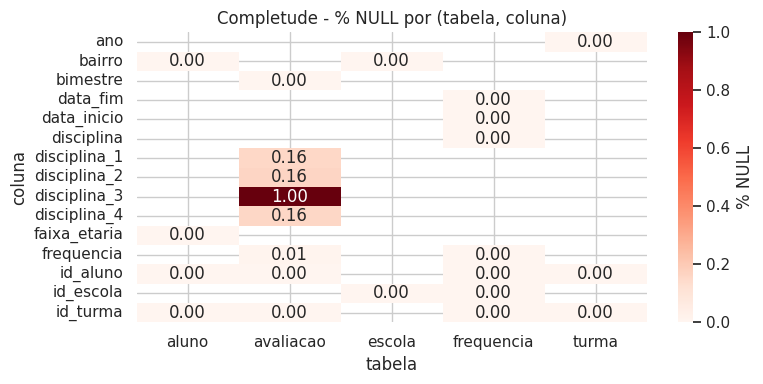

  -> salvo: /home/matheus/GitHub/iplan/desafio-rmi/exploratory_data_analysis/figures/dq_completude_top10_null.png


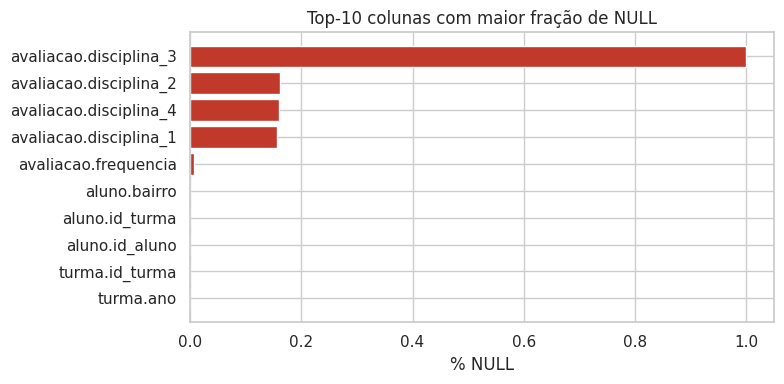

In [13]:
HEATMAP_KW = dict(annot=True, fmt=".2f", cmap="Reds", vmin=0, vmax=1)
TOP_NULL_N = 10
COR_BARRA_NULL = "#c0392b"


def _altura_heatmap(n_linhas: int, altura_por_linha: float = 0.25, minimo: float = 4) -> float:
    return max(minimo, altura_por_linha * n_linhas)


def _heatmap_completude(qual_df: pd.DataFrame) -> None:
    heat = qual_df.pivot_table(
        index="coluna", columns="tabela", values="pct_null", aggfunc="first"
    )
    fig, ax = plt.subplots(figsize=(8, _altura_heatmap(len(heat))))
    sns.heatmap(heat, ax=ax, cbar_kws={"label": "% NULL"}, **HEATMAP_KW)
    ax.set_title("Completude - % NULL por (tabela, coluna)")
    savefig("dq_completude_heatmap_geral")
    plt.show()


def _barh_top_null(qual_df: pd.DataFrame, n: int) -> None:
    top = qual_df.sort_values("pct_null", ascending=False).head(n).copy()
    top["label"] = top["tabela"] + "." + top["coluna"]

    fig, ax = plt.subplots(figsize=(8, 4))
    ax.barh(top["label"][::-1], top["pct_null"][::-1], color=COR_BARRA_NULL)
    ax.set_xlabel("% NULL")
    ax.set_title(f"Top-{n} colunas com maior fração de NULL")
    savefig("dq_completude_top10_null")
    plt.show()


_heatmap_completude(qual)
_barh_top_null(qual, TOP_NULL_N)


### 5.2. Unicidade - linhas totais vs. distintas por PK declarada

                                                              grão   total  distintos  duplicatas
                                                  aluno (id_aluno)   97044      97044           0
                                                escola (id_escola)    1558       1558           0
                                   turma (id_aluno, id_turma, ano)   97044      97044           0
frequencia (id_aluno, id_turma, data_inicio, data_fim, disciplina) 2727684    2725108        2576
                                    avaliacao (id_aluno, bimestre)  221687     221106         581
  -> salvo: /home/matheus/GitHub/iplan/desafio-rmi/exploratory_data_analysis/figures/dq_unicidade_pk_barras.png


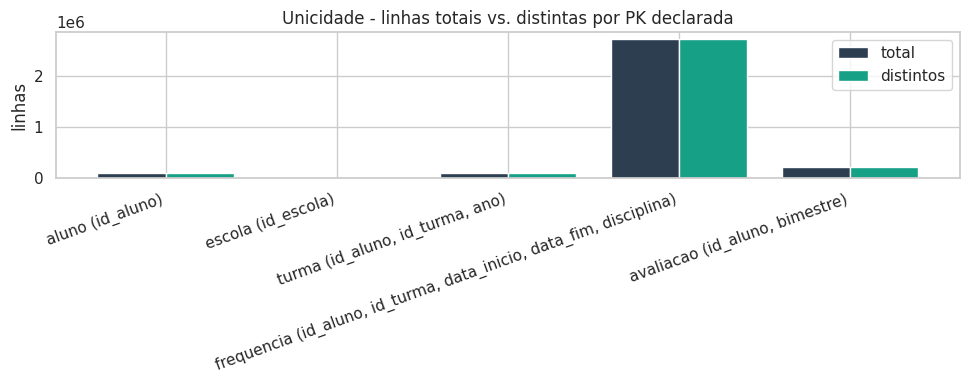

In [14]:
COR_TOTAL = "#2c3e50"
COR_DISTINTOS = "#16a085"
LARGURA_BARRA = 0.4


def _count_rows_pl(lf: pl.LazyFrame) -> int:
    return lf.select(pl.len()).collect().item()


def _count_distinct_pl(lf: pl.LazyFrame, cols: list[str]) -> int:
    return lf.select(cols).unique().select(pl.len()).collect().item()


pk_checks = [
    (
        "aluno (id_aluno)",
        len(df_aluno),
        df_aluno["id_aluno"].nunique(),
    ),
    (
        "escola (id_escola)",
        len(df_escola),
        df_escola["id_escola"].nunique(),
    ),
    (
        "turma (id_aluno, id_turma, ano)",
        len(df_turma),
        df_turma.drop_duplicates().shape[0],
    ),
    (
        "frequencia (id_aluno, id_turma, data_inicio, data_fim, disciplina)",
        _count_rows_pl(lf_frequencia),
        _count_distinct_pl(lf_frequencia, GRAIN_FREQUENCIA),
    ),
    (
        "avaliacao (id_aluno, bimestre)",
        _count_rows_pl(lf_avaliacao),
        _count_distinct_pl(lf_avaliacao, ["id_aluno", "bimestre"]),
    ),
]

pk_df = pd.DataFrame(pk_checks, columns=["grão", "total", "distintos"])
pk_df["duplicatas"] = pk_df["total"] - pk_df["distintos"]
print(pk_df.to_string(index=False))

fig, ax = plt.subplots(figsize=(10, 4))
x = np.arange(len(pk_df))

ax.bar(
    x - LARGURA_BARRA / 2, pk_df["total"],
    width=LARGURA_BARRA, label="total", color=COR_TOTAL,
)
ax.bar(
    x + LARGURA_BARRA / 2, pk_df["distintos"],
    width=LARGURA_BARRA, label="distintos", color=COR_DISTINTOS,
)
ax.set_xticks(x)
ax.set_xticklabels(pk_df["grão"], rotation=20, ha="right")
ax.set_ylabel("linhas")
ax.set_title("Unicidade - linhas totais vs. distintas por PK declarada")
ax.legend()

savefig("dq_unicidade_pk_barras")
plt.show()


### 5.3. Validade - histograma de notas (wide) + bimestre

  -> salvo: /home/matheus/GitHub/iplan/desafio-rmi/exploratory_data_analysis/figures/dq_validade_nota_histograma.png


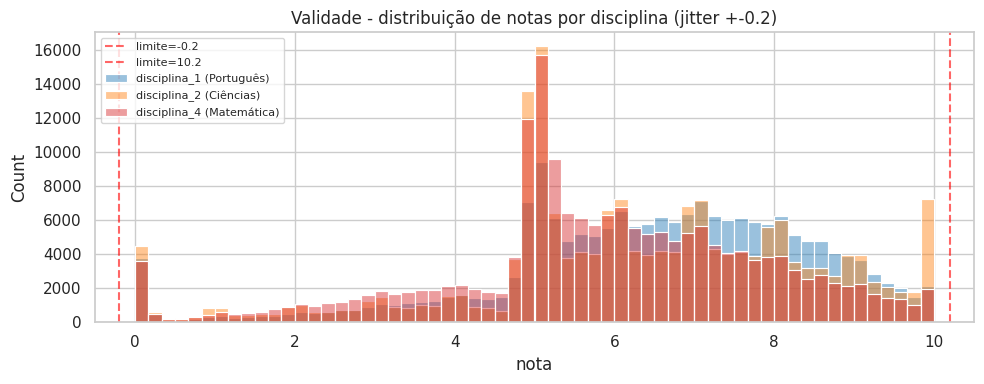

  -> salvo: /home/matheus/GitHub/iplan/desafio-rmi/exploratory_data_analysis/figures/dq_validade_bimestre_barras.png


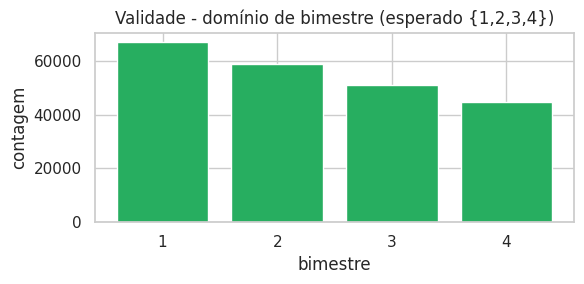

In [15]:
COR_LIMITE_NOTA = "red"
COR_BIMESTRE = "#27ae60"
HIST_BINS = 60
HIST_ALPHA = 0.45


def _array_sem_nulos(lf: pl.LazyFrame, coluna: str) -> np.ndarray:
    return (
        lf.select(pl.col(coluna).drop_nulls())
        .collect()
        .to_series()
        .to_numpy()
    )


def _plot_histograma_notas(lf: pl.LazyFrame, colunas: list[str], faixa: tuple[float, float]) -> None:
    fig, ax = plt.subplots(figsize=(10, 4))
    palette = sns.color_palette("tab10", n_colors=len(colunas))

    for coluna, cor in zip(colunas, palette):
        arr = _array_sem_nulos(lf, coluna)
        if arr.size == 0:
            continue
        sns.histplot(
            arr,
            bins=HIST_BINS,
            ax=ax,
            color=cor,
            alpha=HIST_ALPHA,
            stat="count",
            label=f"{coluna} ({DISCIPLINA_MAP[coluna]})",
        )

    lo, hi = faixa
    for limite in (lo, hi):
        ax.axvline(
            limite,
            color=COR_LIMITE_NOTA,
            linestyle="--",
            alpha=0.6,
            label=f"limite={limite}",
        )
    ax.set_title("Validade - distribuição de notas por disciplina (jitter +-0.2)")
    ax.set_xlabel("nota")
    ax.legend(loc="upper left", fontsize=8)

    savefig("dq_validade_nota_histograma")
    plt.show()


def _plot_bimestre_barras(lf: pl.LazyFrame) -> None:
    bim = lf.group_by("bimestre").len().sort("bimestre").collect().to_pandas()

    fig, ax = plt.subplots(figsize=(6, 3))
    ax.bar(bim["bimestre"], bim["len"], color=COR_BIMESTRE)
    ax.set_xlabel("bimestre")
    ax.set_ylabel("contagem")
    ax.set_title("Validade - domínio de bimestre (esperado {1,2,3,4})")

    savefig("dq_validade_bimestre_barras")
    plt.show()


_plot_histograma_notas(lf_avaliacao, DISC_COLS, NOTA_RANGE)
_plot_bimestre_barras(lf_avaliacao)


### 5.4. Consistência referencial - match rate por FK (anti-joins)

                            fk   total  orfaos  pct_orfaos
  frequencia.id_aluno -> aluno 2727684       0      0.0000
  frequencia.id_turma -> turma 2727684  338536      0.1241
frequencia.id_escola -> escola 2727684       0      0.0000
   avaliacao.id_aluno -> aluno  221687       0      0.0000
   avaliacao.id_turma -> turma  221687     184      0.0008
       turma.id_aluno -> aluno   97044       0      0.0000
  -> salvo: /home/matheus/GitHub/iplan/desafio-rmi/exploratory_data_analysis/figures/dq_consistencia_fks_barras.png


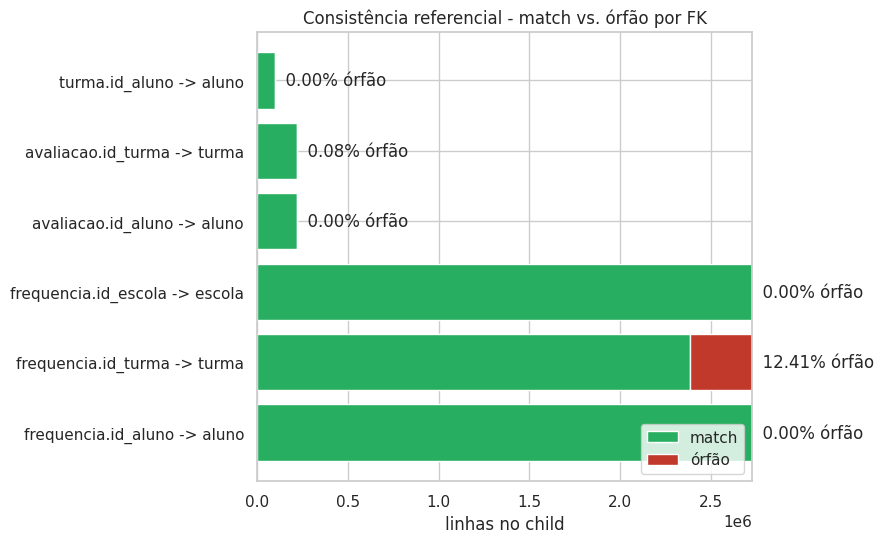

In [16]:
from typing import NamedTuple

COR_MATCH = "#27ae60"
COR_ORFAO = "#c0392b"


class FKTest(NamedTuple):
    label: str
    child: str
    child_col: str
    parent: str
    parent_col: str


FK_TESTS = [
    FKTest("frequencia.id_aluno -> aluno", "frequencia", "id_aluno", "aluno", "id_aluno"),
    FKTest("frequencia.id_turma -> turma", "frequencia", "id_turma", "turma", "id_turma"),
    FKTest("frequencia.id_escola -> escola", "frequencia", "id_escola", "escola", "id_escola"),
    FKTest("avaliacao.id_aluno -> aluno",   "avaliacao",  "id_aluno", "aluno", "id_aluno"),
    FKTest("avaliacao.id_turma -> turma",   "avaliacao",  "id_turma", "turma", "id_turma"),
    FKTest("turma.id_aluno -> aluno",       "turma",      "id_aluno", "aluno", "id_aluno"),
]


def anti_join(
    child_path: Path, child_col: str,
    parent_path: Path, parent_col: str,
) -> tuple[int, int]:
    child = (
        pl.scan_parquet(child_path)
        .select([child_col])
        .rename({child_col: "k"})
    )
    parent = (
        pl.scan_parquet(parent_path)
        .select([parent_col])
        .rename({parent_col: "k"})
        .unique()
    )
    orfaos = child.join(parent, on="k", how="anti").select(pl.len()).collect().item()
    total = child.select(pl.len()).collect().item()
    return orfaos, total


def _checa_fk(fk: FKTest) -> dict:
    orfaos, total = anti_join(
        PARQUETS[fk.child], fk.child_col,
        PARQUETS[fk.parent], fk.parent_col,
    )
    return {
        "fk": fk.label,
        "total": total,
        "orfaos": orfaos,
        "pct_orfaos": orfaos / total,
    }


fk_df = pd.DataFrame([_checa_fk(fk) for fk in FK_TESTS])
print(fk_df.to_string(index=False, float_format="%.4f"))

fk_df["match"] = fk_df["total"] - fk_df["orfaos"]

fig, ax = plt.subplots(figsize=(9, 0.6 * len(fk_df) + 2))
y = np.arange(len(fk_df))

ax.barh(y, fk_df["match"], color=COR_MATCH, label="match")
ax.barh(y, fk_df["orfaos"], left=fk_df["match"], color=COR_ORFAO, label="órfão")
ax.set_yticks(y)
ax.set_yticklabels(fk_df["fk"])

for i, row in enumerate(fk_df.itertuples()):
    ax.text(row.total, i, f"  {row.pct_orfaos * 100:.2f}% órfão", va="center")

ax.set_xlabel("linhas no child")
ax.set_title("Consistência referencial - match vs. órfão por FK")
ax.legend(loc="lower right")

savefig("dq_consistencia_fks_barras")
plt.show()


### 5.5. Acurácia - proxy - (valores inverossímeis)

                                                regra  violacoes   total    pct
                        frequencia.data_inicio > hoje          0 2727684 0.0000
                    frequencia.data_inicio > data_fim          0 2727684 0.0000
              frequencia.frequencia fora (0.0, 100.0)          0 2727684 0.0000
                    avaliacao.bimestre fora {1,2,3,4}          0  221687 0.0000
               avaliacao.frequencia fora (0.0, 100.0)          0  221687 0.0000
 avaliacao.disciplina_1 (Português) fora (-0.2, 10.2)          0  221687 0.0000
  avaliacao.disciplina_2 (Ciências) fora (-0.2, 10.2)          0  221687 0.0000
    avaliacao.disciplina_3 (Inglês) fora (-0.2, 10.2)          0  221687 0.0000
avaliacao.disciplina_4 (Matemática) fora (-0.2, 10.2)          0  221687 0.0000
  -> salvo: /home/matheus/GitHub/iplan/desafio-rmi/exploratory_data_analysis/figures/dq_acuracia_regras_barras.png


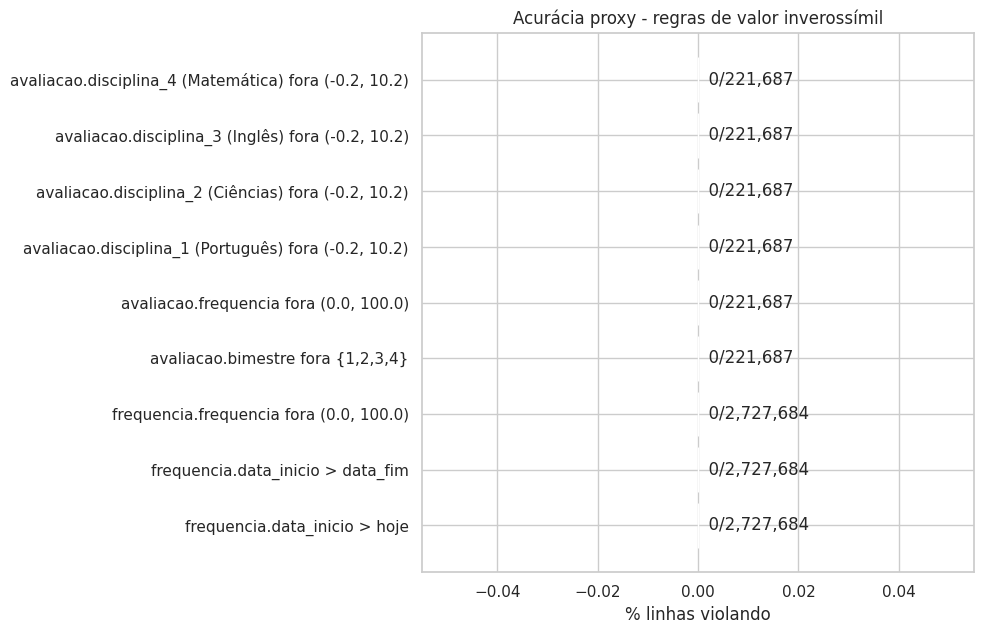

In [17]:
from datetime import date

COR_BARRA_REGRAS = "#e67e22"
BIMESTRES_VALIDOS = ["1", "2", "3", "4"]


def _count_total(lf: pl.LazyFrame) -> int:
    return lf.select(pl.len()).collect().item()


def _count_filtro(lf: pl.LazyFrame, predicado: pl.Expr) -> int:
    return lf.filter(predicado).select(pl.len()).collect().item()


def _fora_intervalo(coluna: str, faixa: tuple) -> pl.Expr:
    return (pl.col(coluna) < faixa[0]) | (pl.col(coluna) > faixa[1])


hoje = date.today()
data_inicio = pl.col("data_inicio").str.to_date("%Y-%m-%d", strict=False)
data_fim = pl.col("data_fim").str.to_date("%Y-%m-%d", strict=False)

total_freq = _count_total(lf_frequencia)
total_aval = _count_total(lf_avaliacao)

regras = [
    (
        "frequencia.data_inicio > hoje",
        _count_filtro(lf_frequencia, data_inicio > pl.lit(hoje)),
        total_freq,
    ),
    (
        "frequencia.data_inicio > data_fim",
        _count_filtro(lf_frequencia, data_inicio > data_fim),
        total_freq,
    ),
    (
        f"frequencia.frequencia fora {FREQ_RANGE}",
        _count_filtro(lf_frequencia, _fora_intervalo("frequencia", FREQ_RANGE)),
        total_freq,
    ),
    (
        "avaliacao.bimestre fora {1,2,3,4}",
        _count_filtro(lf_avaliacao, ~pl.col("bimestre").is_in(BIMESTRES_VALIDOS)),
        total_aval,
    ),
    (
        f"avaliacao.frequencia fora {FREQ_RANGE}",
        _count_filtro(
            lf_avaliacao,
            pl.col("frequencia").is_not_null() & _fora_intervalo("frequencia", FREQ_RANGE),
        ),
        total_aval,
    ),
]

for c in DISC_COLS:
    predicado = pl.col(c).is_not_null() & _fora_intervalo(c, NOTA_RANGE)
    viola = _count_filtro(lf_avaliacao, predicado)
    regras.append(
        (f"avaliacao.{c} ({DISCIPLINA_MAP[c]}) fora {NOTA_RANGE}", viola, total_aval)
    )

reg_df = pd.DataFrame(regras, columns=["regra", "violacoes", "total"])
reg_df["pct"] = reg_df["violacoes"] / reg_df["total"]
print(reg_df.to_string(index=False, float_format="%.4f"))

fig, ax = plt.subplots(figsize=(10, 0.5 * len(reg_df) + 2))
ax.barh(reg_df["regra"], reg_df["pct"] * 100, color=COR_BARRA_REGRAS)
ax.set_xlabel("% linhas violando")
ax.set_title("Acurácia proxy - regras de valor inverossímil")

for i, (v, t) in enumerate(zip(reg_df["violacoes"], reg_df["total"])):
    ax.text(0, i, f"  {v:,}/{t:,}", va="center")

savefig("dq_acuracia_regras_barras")
plt.show()


### 5.6. Temporalidade (linha mensal de frequencia + bimestre de avaliação)

  -> salvo: /home/matheus/GitHub/iplan/desafio-rmi/exploratory_data_analysis/figures/dq_temporalidade_frequencia_linha.png


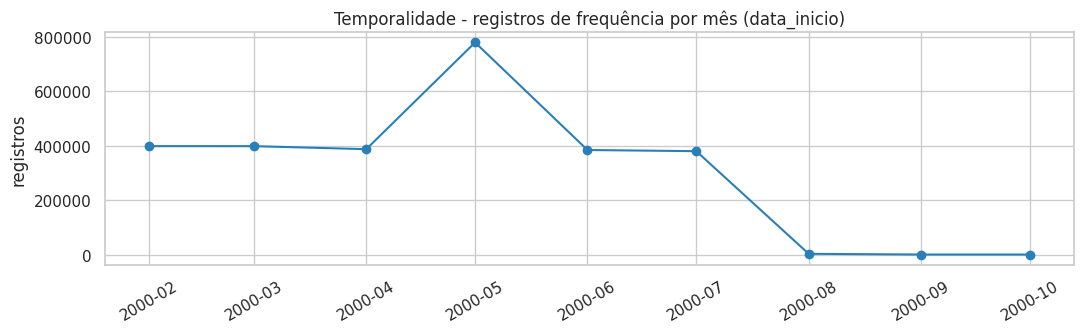

  -> salvo: /home/matheus/GitHub/iplan/desafio-rmi/exploratory_data_analysis/figures/dq_temporalidade_avaliacao_linha.png


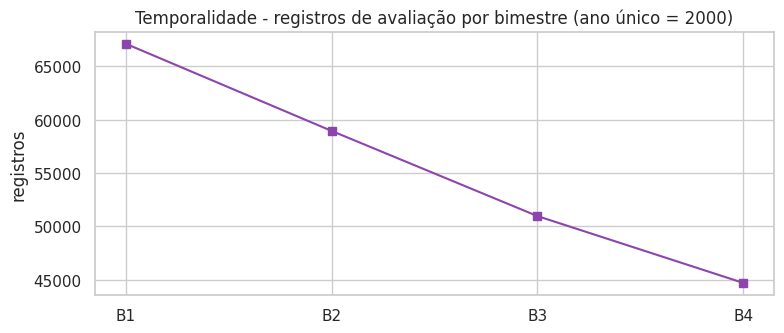

In [18]:
COR_FREQ_MENSAL = "#2980b9"
COR_AVAL_BIMESTRE = "#8e44ad"


def _serie_frequencia_mensal(lf: pl.LazyFrame) -> pd.DataFrame:
    return (
        lf.with_columns(data_inicio.dt.truncate("1mo").alias("mes"))
        .group_by("mes").len()
        .sort("mes")
        .collect()
        .to_pandas()
    )


def _serie_avaliacao_bimestre(lf: pl.LazyFrame) -> pd.DataFrame:
    df = (
        lf.group_by("bimestre").len()
        .sort("bimestre")
        .collect()
        .to_pandas()
    )
    df["label"] = "B" + df["bimestre"].astype(str)
    return df


mensal = _serie_frequencia_mensal(lf_frequencia)
fig, ax = plt.subplots(figsize=(11, 3.5))
ax.plot(mensal["mes"], mensal["len"], marker="o", color=COR_FREQ_MENSAL)
ax.set_title("Temporalidade - registros de frequência por mês (data_inicio)")
ax.set_ylabel("registros")
ax.tick_params(axis="x", rotation=30)
savefig("dq_temporalidade_frequencia_linha")
plt.show()


g = _serie_avaliacao_bimestre(lf_avaliacao)
fig, ax = plt.subplots(figsize=(8, 3.5))
ax.plot(g["label"], g["len"], marker="s", color=COR_AVAL_BIMESTRE)
ax.set_title("Temporalidade - registros de avaliação por bimestre (ano único = 2000)")
ax.set_ylabel("registros")
savefig("dq_temporalidade_avaliacao_linha")
plt.show()


## 6. Cross-table

### 6.1. Coerência de cadastro

Como `turma` é listagem (1:1 alunoXturma no ano 2000), aluno em múltiplas
turmas só pode emergir via `frequencia`. Turma em múltiplas escolas é uma
regra de negócio - também verificado via `frequencia`.

In [19]:
def _conta_multi(lf: pl.LazyFrame, agrupador: str, alvo: str) -> int:
    return (
        lf.select([agrupador, alvo]).unique()
        .group_by(agrupador).len()
        .filter(pl.col("len") > 1)
        .select(pl.len())
        .collect()
        .item()
    )


multi_turmas = _conta_multi(lf_frequencia, "id_aluno", "id_turma")
print(f"Alunos em múltiplas turmas (via frequencia): {multi_turmas:,}")

multi_escolas = _conta_multi(lf_frequencia, "id_turma", "id_escola")
print(f"Turmas em múltiplas escolas (via frequencia): {multi_escolas:,}")

# Coerência aluno.id_turma (ponteiro corrente) vs. listagem turma.
aluno_mais_turma = df_aluno.merge(
    df_turma, on=["id_aluno", "id_turma"], how="left", indicator=True
)
inconsistentes = (aluno_mais_turma["_merge"] != "both").sum()
print(f"Linhas em aluno com (id_aluno, id_turma) ausente no listagem: {inconsistentes:,}")


Alunos em múltiplas turmas (via frequencia): 8,162
Turmas em múltiplas escolas (via frequencia): 0
Linhas em aluno com (id_aluno, id_turma) ausente no listagem: 0


### 6.2. Volumetria por grão candidato do mart

`avaliacao` não tem ano/mês - a janela temporal é bimestre. `frequencia`
tem períodos mensais via `data_inicio`. Grãos candidatos abaixo usam o
que o schema real oferece.

In [20]:
mes_expr = data_inicio.dt.truncate("1mo").alias("mes")


def _contar_distintos_mes(lf: pl.LazyFrame, cols: list[str]) -> int:
    return (
        lf.with_columns(mes_expr)
        .select(cols)
        .unique()
        .select(pl.len())
        .collect()
        .item()
    )


def _contar_distintos(lf: pl.LazyFrame, cols: list[str]) -> int:
    return (
        lf.select(cols)
        .unique()
        .select(pl.len())
        .collect()
        .item()
    )


pares_esc_turma = lf_frequencia.select(["id_escola", "id_turma"]).unique()
pares_turma_bim = lf_avaliacao.select(["id_turma", "bimestre"]).unique()
escola_x_bimestre = (
    pares_esc_turma.join(pares_turma_bim, on="id_turma", how="inner")
    .select(["id_escola", "bimestre"])
    .unique()
    .select(pl.len())
    .collect()
    .item()
)

graos = [
    ("escola x ano (ano único = 2000)", len(df_escola)),
    ("escola x mês (frequencia)",                _contar_distintos_mes(lf_frequencia, ["id_escola", "mes"])),
    ("aluno x mês (frequencia)",                 _contar_distintos_mes(lf_frequencia, ["id_aluno", "mes"])),
    ("aluno x disciplina x mês (frequencia)",    _contar_distintos_mes(lf_frequencia, ["id_aluno", "disciplina", "mes"])),
    ("aluno x bimestre (avaliacao)",             _contar_distintos(lf_avaliacao, ["id_aluno", "bimestre"])),
    ("turma x bimestre (avaliacao)",             _contar_distintos(lf_avaliacao, ["id_turma", "bimestre"])),
    # proxy: avaliacao não tem id_escola, então pareamos via id_turma da frequencia.
    ("escola x bimestre (frequencia X avaliacao)", escola_x_bimestre),
]

graos_df = (
    pd.DataFrame(graos, columns=["grão", "linhas_estimadas"])
    .sort_values("linhas_estimadas")
    .reset_index(drop=True)
)
print(graos_df.to_string(index=False))


                                      grão  linhas_estimadas
           escola x ano (ano único = 2000)              1558
escola x bimestre (frequencia X avaliacao)              1697
                 escola x mês (frequencia)              3132
              turma x bimestre (avaliacao)             25304
              aluno x bimestre (avaliacao)            221106
                  aluno x mês (frequencia)            571222
     aluno x disciplina x mês (frequencia)           2284888
